# Hopper-v4 – REINFORCE & Actor-Critic

This notebook trains and evaluates a control policy on the **Hopper-v4** environment from Gymnasium (the updated fork of OpenAI Gym).

The Hopper is a 2D one-legged robot that has to learn how to hop forward as fast as possible without falling over. The agent only sees joint angles and velocities – it can't see the x-position directly.

We implement two algorithms:
- **REINFORCE** (Monte Carlo Policy Gradient): collect a full episode, then update the policy using the discounted returns.
- **Actor-Critic** (TASK 3, to be implemented): instead of waiting for the full episode, we use a value function (critic) to estimate returns step by step.

Works both on **Google Colab** and locally.

In [1]:
import sys, os, subprocess

# Check if we are running on Google Colab or locally.
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    REPO_URL    = "https://github.com/Gianbattistabsn/FAIML-RL-26.git"
    REPO_BRANCH = "part1-gian-gabri"
    REPO_ROOT   = "/content/FAIML-RL-26"

    if not os.path.exists(REPO_ROOT):
        # Try cloning the specific branch directly.
        # Capture output so we can print the real git error if it fails.
        result = subprocess.run(
            ["git", "clone", "--branch", REPO_BRANCH, REPO_URL, REPO_ROOT],
            capture_output=True, text=True
        )
        if result.returncode != 0:
            # Fallback: clone default branch then checkout the right one
            print("Branch clone failed, falling back to clone + checkout")
            print("git stderr:", result.stderr.strip())
            subprocess.run(["git", "clone", REPO_URL, REPO_ROOT], check=True)
            subprocess.run(["git", "-C", REPO_ROOT, "checkout", REPO_BRANCH], check=True)
    else:
        # Repo already exists: fetch + checkout correct branch + pull
        subprocess.run(["git", "-C", REPO_ROOT, "fetch", "origin"], check=True)
        subprocess.run(["git", "-C", REPO_ROOT, "checkout", REPO_BRANCH], check=True)
        subprocess.run(["git", "-C", REPO_ROOT, "pull", "origin", REPO_BRANCH], check=True)

    subprocess.run(["apt-get", "install", "-y", "ffmpeg"], capture_output=True)
else:
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

os.chdir(REPO_ROOT)
sys.path.insert(0, os.path.join(REPO_ROOT, "part1"))

subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt", "-q"], check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "pyvirtualdisplay", "-q"], check=False)

print(f"Mode      : {'Colab' if IN_COLAB else 'Local'}")
print(f"Repo root : {REPO_ROOT}")
if IN_COLAB:
    branch = subprocess.run(
        ["git", "-C", REPO_ROOT, "branch", "--show-current"],
        capture_output=True, text=True
    ).stdout.strip()
    print(f"Branch    : {branch}")
    if branch != REPO_BRANCH:
        raise RuntimeError(f"Wrong branch! Expected '{REPO_BRANCH}', got '{branch}'")


Mode      : Local
Repo root : c:\Users\gianb\Desktop\Data_Science_and_Eng\Year1Sem2\Fundamentals\project\FAIML-RL-26


In [2]:
import datetime       # used to timestamp checkpoint filenames
import numpy as np    # for array operations and computing means
import gymnasium as gym  # the RL environment library
import torch          # PyTorch – used for the neural network policy
import matplotlib.pyplot as plt  # for plotting the training curve

# Import our custom Policy network and Agent class from part1/agent.py
from agent import Agent, Policy

# Start a virtual display so gymnasium can render without a physical monitor.
# This is required on Colab and on any headless machine.
# On a local machine with a desktop this will just fail silently, which is fine.
try:
    from pyvirtualdisplay import Display
    display = Display(visible=False, size=(1400, 900))
    display.start()
    print("Virtual display started")
except Exception as e:
    # No virtual display needed when running locally with a real monitor
    print(f"Virtual display not started ({e}) – that's fine if running locally")

Virtual display not started ([WinError 2] Impossibile trovare il file specificato) – that's fine if running locally


---
## Environment Info

Before training anything it's useful to understand what the environment actually looks like.

- **State space**: the observation the agent receives at each timestep. For Hopper-v4 this is a vector of 11 continuous values (joint angles + velocities). It's a `Box` space, meaning each element can be any real number within a range.
- **Action space**: what the agent can do. For Hopper-v4 this is a vector of 3 continuous torques (one per joint), each clipped to `[-1, 1]`.

Both spaces are continuous, so we can't use simple Q-tables – we need a neural network to approximate the policy.

In [3]:
# Create the environment just to inspect its spaces, then close it immediately
env = gym.make('Hopper-v4')

# observation_space tells us the shape of the state vector the agent receives
# -> Box(-inf, inf, shape=(11,), dtype=float64)
print('State space  :', env.observation_space)

# action_space tells us the shape of the action vector the agent must produce
# -> Box(-1.0, 1.0, shape=(3,), dtype=float32)
print('Action space :', env.action_space)

env.close()  # always close the environment when done to free resources

State space  : Box(-inf, inf, (11,), float64)
Action space : Box(-1.0, 1.0, (3,), float32)


C:\Users\gianb\AppData\Roaming\Python\Python313\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


---
## Random Policy Demo

Before training, it's good to run a **random policy** as a baseline. A random policy just samples a random action at every step, completely ignoring the state. This tells us:

1. That the environment is set up correctly and we can run episodes.
2. What the **minimum expected reward** is (anything below this would mean our trained agent is doing worse than random, which would be a bug).

Typically a random policy on Hopper-v4 gets very low rewards because the robot falls almost immediately.

In [4]:
# rgb_array mode returns frames as numpy arrays instead of opening a window
# (needed for headless environments like Colab)
env = gym.make('Hopper-v4', render_mode='rgb_array')

n_episodes = 3
ep_rewards = []

for ep in range(n_episodes):
    done = False
    obs, _ = env.reset()   # reset returns (observation, info) in Gymnasium
    ep_reward = 0.0

    while not done:
        # Sample a completely random action from the action space
        # This ignores the observation entirely
        action = env.action_space.sample()

        # Step the simulation: returns next obs, reward, terminated, truncated, info
        # terminated = the episode ended naturally (e.g. robot fell)
        # truncated  = the episode hit the max step limit
        obs, reward, terminated, truncated, _ = env.step(action)
        ep_reward += reward

        # The episode is over if EITHER condition is met
        done = terminated or truncated

    ep_rewards.append(ep_reward)
    print(f"Episode {ep+1}: reward = {ep_reward:.2f}")

env.close()
print(f"\nMean reward (random policy): {np.mean(ep_rewards):.2f}")

Episode 1: reward = 110.18
Episode 2: reward = 13.37
Episode 3: reward = 10.42

Mean reward (random policy): 44.66


---
## Configuration

Set all hyperparameters here before running the training loop.

- **ALGORITHM**: which policy gradient algorithm to use (`reinforce` or `actor_critic`).
- **BASELINE** controls how the advantage signal is computed for REINFORCE:
  - `-1` → **adaptive**: subtracts the moving average of the last 100 episode returns. Automatically tracks the current performance level, keeping gradients centred without manual tuning.
  - `0` → **G_t whitening**: normalises returns to zero mean and unit std within each episode. Keeps gradient scale constant regardless of absolute reward magnitude.
  - `>0` → **fixed constant**: subtracts a fixed value from every G_t (e.g. `20`). Simple but requires manual tuning and becomes stale as performance improves.
  - _For `actor_critic` the baseline is unused (the critic provides the advantage directly)._
- **NUM_EPISODES**: how many full episodes to collect. More = longer training but (hopefully) better performance.
- **SEED**: random seed for reproducibility.
- Checkpoints are saved every time a new best 100-episode average is found, plus once at the very end.


In [5]:
ALGORITHM           = 'reinforce'   # 'reinforce' | 'actor_critic'
# Baseline options for REINFORCE:
#   -1  -> adaptive: moving average of the last 100 episode returns (tracks current performance)
#    0  -> G_t whitening: normalise returns to mean=0, std=1 within each episode
#   >0  -> fixed constant subtracted from G_t (e.g. 20)
BASELINE            = 0
NUM_EPISODES        = 5000
SEED                = 42

# Use the same folder convention as train.py standalone:
# part1/checkpoints/{algorithm}_baseline_{baseline}/
# This way checkpoints from the notebook and from the command line end up in the same place.
CHECKPOINT_DIR = os.path.join(REPO_ROOT, "part1", "checkpoints", f"{ALGORITHM}_baseline_{BASELINE}")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Algorithm   : {ALGORITHM}")
print(f"Baseline    : {BASELINE}  ({'adaptive moving avg' if BASELINE == -1 else 'G_t whitening' if BASELINE == 0 else f'fixed constant {BASELINE}'})")
print(f"Episodes    : {NUM_EPISODES}")
print(f"Checkpoints : {CHECKPOINT_DIR}")


Algorithm   : reinforce
Baseline    : 0  (G_t whitening)
Episodes    : 5000
Checkpoints : c:\Users\gianb\Desktop\Data_Science_and_Eng\Year1Sem2\Fundamentals\project\FAIML-RL-26\part1\checkpoints\reinforce_baseline_0


---
## Training

In [6]:

from train import train

# train() returns:
#   policy         – the trained neural network
#   ep_rewards     – list of total reward per episode
#   ep_lengths     – list of episode length (steps) per episode
#   ep_losses      – list of actor loss values (one per episode)
#   sigma_history  – list of (episode, sigma_array) snapshots every 100 eps
#   final_ckpt     – path to the saved final checkpoint file on disk
policy, ep_rewards, ep_lengths, ep_actor_losses, ep_critic_losses, sigma_history, final_ckpt = train(
    algorithm=ALGORITHM,
    baseline=BASELINE,
    num_episodes=NUM_EPISODES,
    seed=SEED,
    checkpoint_dir=CHECKPOINT_DIR,
)
print(f"\nTraining done. Final checkpoint: {final_ckpt}")


Ep    100/5000 | avg:    -0.2  min:    -4.3  max:     4.7 | len:    10 | actor loss:   0.0355 | critic loss:   0.0355 | σ: [0.976, 0.976, 0.982] | best: -inf
  → New best! Saved to reinforce_best_ep100_avg-0.pt
Ep    200/5000 | avg:     0.4  min:    -4.5  max:     6.6 | len:    10 | actor loss:   0.0007 | critic loss:   0.0007 | σ: [0.975, 0.976, 0.986] | best: -0.2
  → New best! Saved to reinforce_best_ep200_avg0.pt
Ep    300/5000 | avg:    -0.3  min:    -4.5  max:     6.4 | len:    12 | actor loss:   0.0372 | critic loss:   0.0372 | σ: [0.977, 0.975, 0.995] | best: 0.4
Ep    400/5000 | avg:    -0.1  min:    -4.9  max:     3.9 | len:    13 | actor loss:   0.0003 | critic loss:   0.0003 | σ: [0.985, 0.968, 0.995] | best: 0.4
Ep    500/5000 | avg:    -0.4  min:    -4.0  max:     4.1 | len:    16 | actor loss:  -0.0394 | critic loss:  -0.0394 | σ: [0.979, 0.965, 0.990] | best: 0.4
Ep    600/5000 | avg:     0.2  min:    -4.3  max:     6.5 | len:    16 | actor loss:   0.0015 | critic loss:

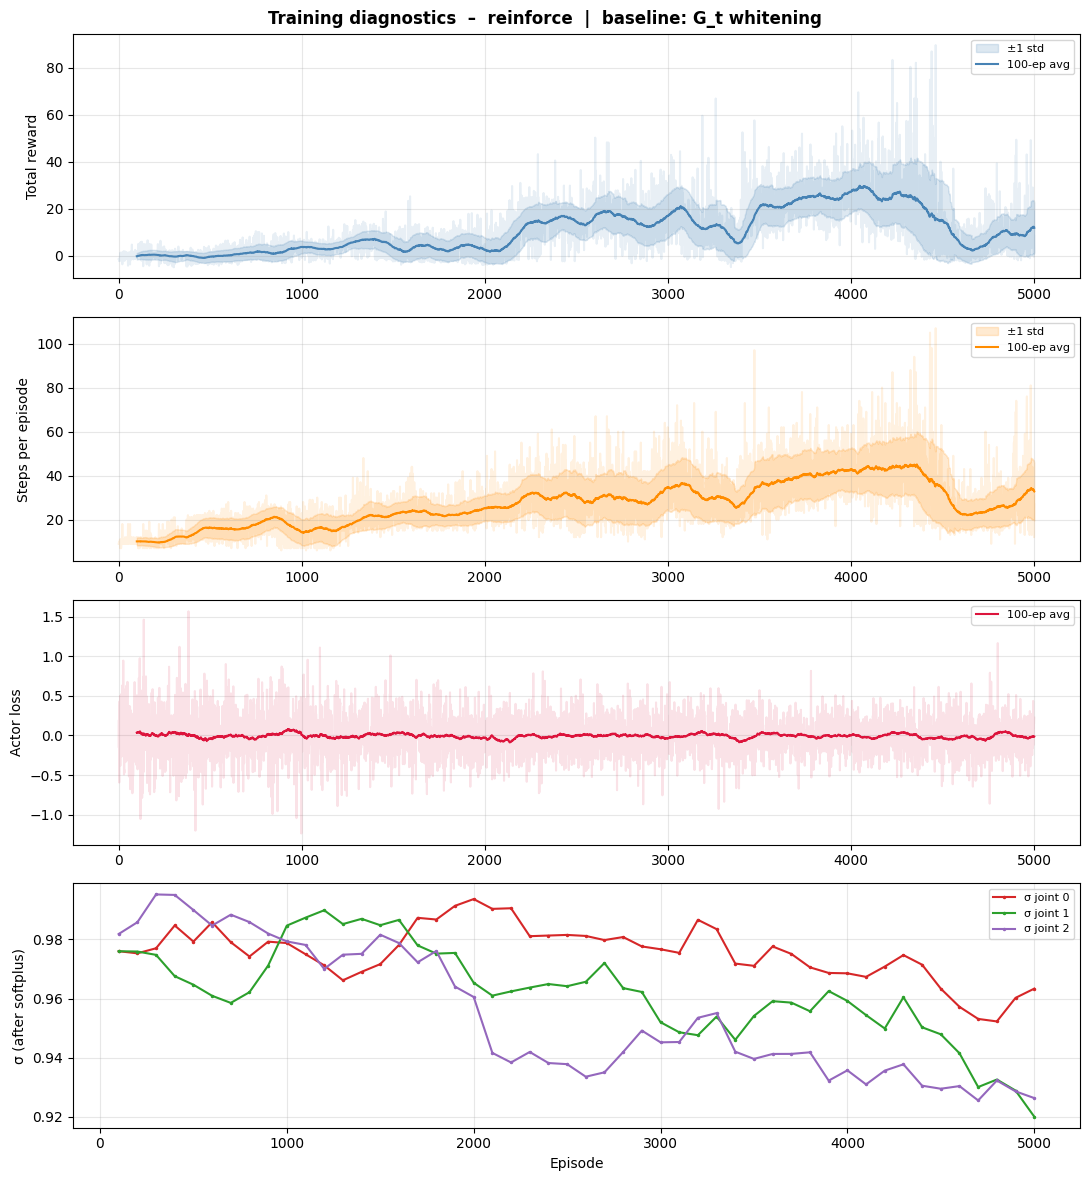

In [10]:

window = min(100, len(ep_rewards))

def moving_avg(data, w):
    return np.convolve(data, np.ones(w) / w, mode='valid')

def moving_std(data, w):
    arr = np.array(data)
    return np.array([arr[i - w + 1 : i + 1].std() for i in range(w - 1, len(arr))])

# ── Smoothed series ──────────────────────────────────────────────────────────
x_smooth = np.arange(window - 1, len(ep_rewards))

reward_smooth = moving_avg(ep_rewards, window)
reward_std    = moving_std(ep_rewards, window)

length_smooth = moving_avg(ep_lengths, window)
length_std    = moving_std(ep_lengths, window)

actor_loss_smooth  = moving_avg(ep_actor_losses,  window) if len(ep_actor_losses)  >= window else np.array(ep_actor_losses)
critic_loss_smooth = moving_avg(ep_critic_losses, window) if len(ep_critic_losses) >= window else np.array(ep_critic_losses)

sigma_eps    = [s[0] for s in sigma_history]
sigma_values = np.array([s[1] for s in sigma_history])   # shape (N_snapshots, n_joints)

# ── Layout: hide critic panel for REINFORCE (actor_loss == critic_loss there) ─
show_critic = ALGORITHM == 'actor_critic'
n_panels    = 5 if show_critic else 4

baseline_label = (
    'adaptive moving avg'  if BASELINE == -1 else
    'G_t whitening'        if BASELINE == 0  else
    f'fixed constant {BASELINE}'
)

fig, axes = plt.subplots(n_panels, 1, figsize=(11, 3 * n_panels), sharex=False)
fig.suptitle(
    f'Training diagnostics  –  {ALGORITHM}  |  baseline: {baseline_label}',
    fontsize=12, fontweight='bold'
)

# ── Panel 1: Episode reward ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(ep_rewards, alpha=0.12, color='steelblue')
ax.fill_between(x_smooth, reward_smooth - reward_std, reward_smooth + reward_std,
                alpha=0.18, color='steelblue', label='±1 std')
ax.plot(x_smooth, reward_smooth, color='steelblue', lw=1.5, label=f'{window}-ep avg')
ax.set_ylabel('Total reward')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 2: Episode length ──────────────────────────────────────────────────
ax = axes[1]
ax.plot(ep_lengths, alpha=0.12, color='darkorange')
ax.fill_between(x_smooth, length_smooth - length_std, length_smooth + length_std,
                alpha=0.18, color='darkorange', label='±1 std')
ax.plot(x_smooth, length_smooth, color='darkorange', lw=1.5, label=f'{window}-ep avg')
ax.set_ylabel('Steps per episode')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: Actor loss ──────────────────────────────────────────────────────
ax = axes[2]
ax.plot(ep_actor_losses, alpha=0.12, color='crimson')
if len(ep_actor_losses) >= window:
    ax.plot(range(window - 1, len(ep_actor_losses)), actor_loss_smooth,
            color='crimson', lw=1.5, label=f'{window}-ep avg')
ax.set_ylabel('Actor loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 4 (actor_critic only): Critic loss ────────────────────────────────
if show_critic:
    ax = axes[3]
    ax.plot(ep_critic_losses, alpha=0.12, color='mediumpurple')
    if len(ep_critic_losses) >= window:
        ax.plot(range(window - 1, len(ep_critic_losses)), critic_loss_smooth,
                color='mediumpurple', lw=1.5, label=f'{window}-ep avg')
    ax.set_ylabel('Critic loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Last panel: σ per joint ──────────────────────────────────────────────────
ax = axes[-1]
colors = ['tab:red', 'tab:green', 'tab:purple']
for j in range(sigma_values.shape[1]):
    ax.plot(sigma_eps, sigma_values[:, j],
            color=colors[j], marker='.', markersize=3, label=f'σ joint {j}')
ax.set_ylabel('σ (after softplus)')
ax.set_xlabel('Episode')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## Evaluate Trained Policy

Now we load a saved checkpoint and run the agent **deterministically** (no exploration): instead of sampling from the Gaussian distribution, we just take the mean action at every step.

We also use gymnasium's `RecordVideo` wrapper to save an `.mp4` of the agent so we can watch it.

In [8]:
# List all .pt files in the checkpoint directory so we can pick one to evaluate
ckpts = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.pt')])
for idx, c in enumerate(ckpts):
    print(f"[{idx}] {c}")

# Change CHECKPOINT_IDX to select a specific checkpoint.
# -1 means the last one in alphabetical order (usually the most recent final checkpoint).
CHECKPOINT_IDX = -1
CHECKPOINT_TO_LOAD = ckpts[CHECKPOINT_IDX] if ckpts else None
print(f"\nSelected: {CHECKPOINT_TO_LOAD}")

[0] reinforce_2026-05-07_09-52-32_311898_25000_12.5.pt
[1] reinforce_2026-05-07_23-20-30_3254775_20000_162.7.pt
[2] reinforce_2026-05-08_19-51-21_26698_5000_5.3.pt
[3] reinforce_2026-05-09_12-09-03_52750_5000_10.5.pt
[4] reinforce_best_ep19700_avg305.pt
[5] reinforce_best_ep4100_avg29.pt
[6] reinforce_best_ep4900_avg22.pt

Selected: reinforce_best_ep4900_avg22.pt


In [9]:
# Import the evaluate() function from test.py.
# Passing video_dir tells it to wrap the env with RecordVideo instead of opening a window –
# useful in Colab where there is no display.
from test import evaluate

# Where to save the recorded .mp4 files
VIDEO_DIR = os.path.join(REPO_ROOT, "part1", "videos")
os.makedirs(VIDEO_DIR, exist_ok=True)

ckpt_path = os.path.join(CHECKPOINT_DIR, CHECKPOINT_TO_LOAD)

# Run 5 deterministic evaluation episodes.
# evaluate() loads the checkpoint, switches to evaluation mode (mean action, no sampling),
# and returns a list with the total reward from each episode.
eval_rewards = evaluate(ckpt_path, num_episodes=5, seed=SEED, video_dir=VIDEO_DIR)

for ep, r in enumerate(eval_rewards, 1):
    print(f"Eval ep {ep}: reward = {r:.2f}")
print(f"\nMean eval reward: {np.mean(eval_rewards):.2f}")

C:\Users\gianb\AppData\Roaming\Python\Python313\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
C:\Users\gianb\AppData\Roaming\Python\Python313\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\gianb\Desktop\Data_Science_and_Eng\Year1Sem2\Fundamentals\project\FAIML-RL-26\part1\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


DependencyNotInstalled: MoviePy is not installed, run `pip install "gymnasium[other]"`

In [ ]:
import base64
from IPython.display import HTML, display as ipy_display

# Find all .mp4 files saved by RecordVideo and display the most recent one inline.
# We encode the video in base64 so it can be embedded directly in the notebook
# without needing a separate file server.
video_files = sorted([f for f in os.listdir(VIDEO_DIR) if f.endswith('.mp4')])

if video_files:
    for i in range(len(video_files)):
      video_path = os.path.join(VIDEO_DIR, video_files[i])
      print(f"Displaying: {video_path}")

      # Read the video file and encode it as base64
      b64 = base64.b64encode(open(video_path, 'rb').read()).decode()

      # Embed the video in an HTML <video> tag
      ipy_display(HTML(
          f'<video width="600" controls autoplay loop>'
          f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
          f'</video>'
      ))
else:
    print("No video files found in", VIDEO_DIR)

Displaying: c:\Users\Utente\Desktop\Fundamentals of AI\gian-gab\FAIML-RL-26\part1\videos\eval-episode-0.mp4


Displaying: c:\Users\Utente\Desktop\Fundamentals of AI\gian-gab\FAIML-RL-26\part1\videos\eval-episode-1.mp4


Displaying: c:\Users\Utente\Desktop\Fundamentals of AI\gian-gab\FAIML-RL-26\part1\videos\eval-episode-2.mp4


Displaying: c:\Users\Utente\Desktop\Fundamentals of AI\gian-gab\FAIML-RL-26\part1\videos\eval-episode-3.mp4


Displaying: c:\Users\Utente\Desktop\Fundamentals of AI\gian-gab\FAIML-RL-26\part1\videos\eval-episode-4.mp4
